# Simulação de Modelo de Fraude
Neste notebook vamos simular dados de Dev e OOT para um modelo de fraude, ajustar uma Regressão Logística, salvar o modelo (.pkl) e salvar a base escorada no SQLite.

In [1]:
import pandas as pd
import numpy as np
import os
import sqlite3
import joblib
from datetime import datetime, timedelta
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Criar os diretórios necessários
os.makedirs('data/artifacts', exist_ok=True)


## 1. Simulação dos Dados
Vamos criar 300 CPF/CNPJ únicos. O período de Dev terá 1 ano de dados e o de OOT terá 4 meses.

In [2]:
np.random.seed(42)

n_entities = 300
cpfs = [f"{str(i).zfill(11)}" for i in range(1, n_entities + 1)]

# Definindo os meses (1 ano de Dev, 4 meses de OOT)
dev_months = pd.date_range(start='2022-01-01', periods=12, freq='MS').strftime('%Y-%m-%d').tolist()
oot_months = pd.date_range(start='2023-01-01', periods=4, freq='MS').strftime('%Y-%m-%d').tolist()

data = []
for cpf in cpfs:
    # Chance base de fraude (para introduzir algum sinal)
    base_fraud_risk = np.random.uniform(0, 1)
    
    # Gerar para Dev
    for month in dev_months:
        data.append({'cpf_cnpj': cpf, 'data_ref': month, 'amostra': 'dev', 'base_risk': base_fraud_risk})
        
    # Gerar para OOT
    for month in oot_months:
        data.append({'cpf_cnpj': cpf, 'data_ref': month, 'amostra': 'oot', 'base_risk': base_fraud_risk})

df = pd.DataFrame(data)


## 2. Criação das Variáveis (Features)
Vamos gerar 20 variáveis explicativas, sendo algumas delas altamente correlacionadas propositalmente.

In [3]:
n_rows = len(df)

# Variáveis independentes normais
for i in range(1, 16):
    df[f'var_{i}'] = np.random.normal(0, 1, n_rows)

# Variáveis correlacionadas
df['var_16'] = df['var_1'] * 2 + np.random.normal(0, 0.5, n_rows)
df['var_17'] = df['var_2'] * 0.5 + np.random.normal(0, 0.1, n_rows)
df['var_18'] = df['var_3'] - np.random.normal(0, 0.2, n_rows)
df['var_19'] = df['var_4'] + df['var_5'] + np.random.normal(0, 0.5, n_rows)
df['var_20'] = df['var_1'] * 3 - df['var_2'] + np.random.normal(0, 1, n_rows)

# Criar o target com base no risco base e algumas variaveis (intercept ajustado para ~3% de taxa de evento)
logit = -4.7 + (df['base_risk'] * 2.5) + (df['var_1'] * 0.8) + (df['var_2'] * -0.5) + (df['var_3'] * 0.3)
prob = 1 / (1 + np.exp(-logit))

# Gerar target final (0 = não fraude, 1 = fraude)
df['target'] = np.random.binomial(1, prob)

# Dropar o base_risk que foi usado só para simulação
df = df.drop(columns=['base_risk'])


## 2.5 Exploratory Data Analysis (EDA)
Vamos visualizar as distribuições e as correlações que injetamos (ex: `var_16` altamente correlacionada com `var_1`).

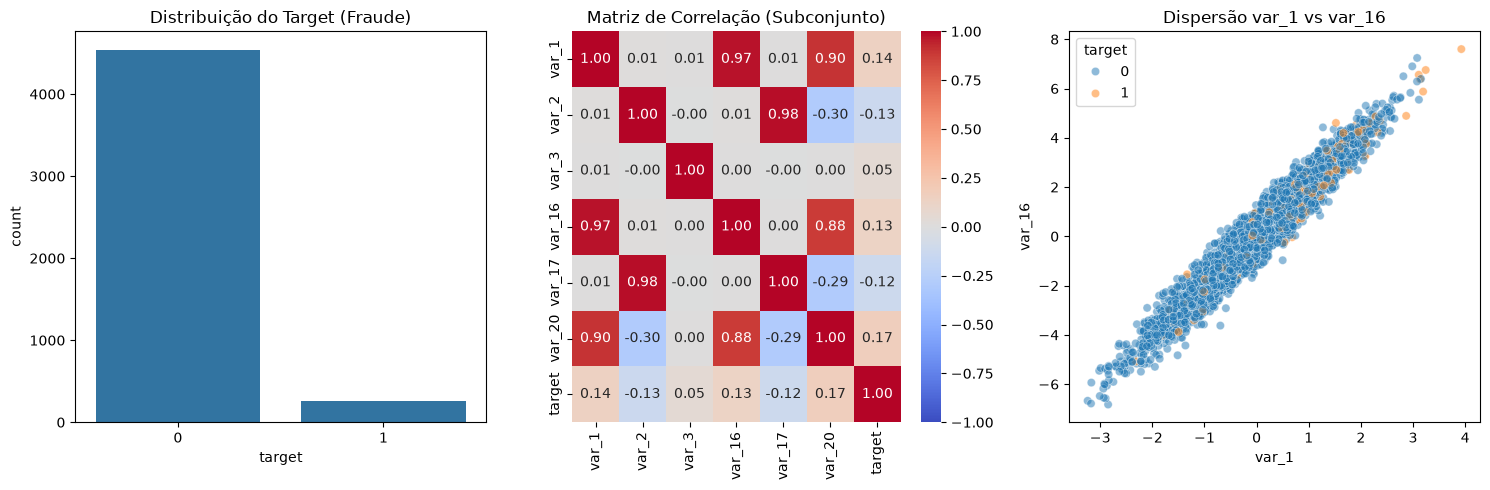

Taxa média de fraude na base: 0.05458333333333333


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 5))

# 1. Distribuição da Variável Target
plt.subplot(1, 3, 1)
sns.countplot(data=df, x='target')
plt.title("Distribuição do Target (Fraude)")

# 2. Relação e correlação entre as features (exibindo um subconjunto)
plt.subplot(1, 3, 2)
cols_corr = ['var_1', 'var_2', 'var_3', 'var_16', 'var_17', 'var_20', 'target']
sns.heatmap(df[cols_corr].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de Correlação (Subconjunto)")

# 3. Dispersão mostrando a correlação entre var_1 e var_16
plt.subplot(1, 3, 3)
sns.scatterplot(data=df, x='var_1', y='var_16', hue='target', alpha=0.5)
plt.title("Dispersão var_1 vs var_16")

plt.tight_layout()
plt.show()

print("Taxa média de fraude na base:", df['target'].mean())


## 3. Modelagem
Separar Dev e treinar a Regressão Logística.

In [5]:
features = [f'var_{i}' for i in range(1, 21)]

df_dev = df[df['amostra'] == 'dev']
df_oot = df[df['amostra'] == 'oot']

X_train = df_dev[features]
y_train = df_dev['target']

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Escorar a base completa (Dev e OOT)
df['score'] = model.predict_proba(df[features])[:, 1]

print("AUC-ROC em DEV:", roc_auc_score(df_dev['target'], df[df['amostra'] == 'dev']['score']))
print("AUC-ROC em OOT:", roc_auc_score(df_oot['target'], df[df['amostra'] == 'oot']['score']))


AUC-ROC em DEV: 0.7373897538665467
AUC-ROC em OOT: 0.7449481481481482


## 4. Salvar Artefatos
Salvar o modelo .pkl e a base escorada no SQLite.

In [6]:
# Salvar o Modelo
joblib.dump(model, 'data/artifacts/modelo_fraude.pkl')
print("Modelo salvo em 'data/artifacts/modelo_fraude.pkl'")

# Salvar no SQLite
conn = sqlite3.connect('data/simulacao.db')

# Salvar a tabela principal (substitui a anterior para limpar o cenário)
df.to_sql('tb_dados_escorados', conn, if_exists='replace', index=False)
print("Base escorada salva na tabela 'tb_dados_escorados' em 'data/simulacao.db'")

conn.close()


Modelo salvo em 'data/artifacts/modelo_fraude.pkl'
Base escorada salva na tabela 'tb_dados_escorados' em 'data/simulacao.db'
